# import relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score)

In [2]:
# Load Your Cleaned Dataset

import pandas as pd

df = pd.read_pickle("cleaned_diabetes.pkl")

df.head()

,Glucose,BloodPressure,BMI,Outcome,Insulin_log,Pregnancies_log,Age_log,DiabetesPedigreeFunction_log,SkinThickness_log
0,148.0,72.0,33.6,1,4.836282,1.945910,3.931826,0.486738,3.583519
1,85.0,66.0,26.6,0,4.836282,0.693147,3.465736,0.300845,3.401197
2,183.0,64.0,23.3,1,4.836282,2.197225,3.496508,0.514021,3.401197
3,89.0,66.0,28.1,0,4.553877,0.693147,3.091042,0.154436,3.178054
4,137.0,40.0,43.1,1,5.129899,0.000000,3.526361,1.190279,3.583519


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Glucose                       768 non-null    float64
 1   BloodPressure                 768 non-null    float64
 2   BMI                           768 non-null    float64
 3   Outcome                       768 non-null    int64  
 4   Insulin_log                   768 non-null    float64
 5   Pregnancies_log               768 non-null    float64
 6   Age_log                       768 non-null    float64
 7   DiabetesPedigreeFunction_log  768 non-null    float64
 8   SkinThickness_log             768 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 54.1 KB


In [4]:
# Reordering the outcome column. Remove 'outcome' column and store it

column_to_move = df.pop('Outcome')

# Add it back to the end
df['Outcome'] = column_to_move
df

,Glucose,BloodPressure,BMI,Insulin_log,Pregnancies_log,Age_log,DiabetesPedigreeFunction_log,SkinThickness_log,Outcome
0,148.0,72.0,33.6,4.836282,1.945910,3.931826,0.486738,3.583519,1
1,85.0,66.0,26.6,4.836282,0.693147,3.465736,0.300845,3.401197,0
2,183.0,64.0,23.3,4.836282,2.197225,3.496508,0.514021,3.401197,1
3,89.0,66.0,28.1,4.553877,0.693147,3.091042,0.154436,3.178054,0
4,137.0,40.0,43.1,5.129899,0.000000,3.526361,1.190279,3.583519,1
...,...,...,...,...,...,...,...,...,...
763,101.0,76.0,32.9,5.198497,2.397895,4.158883,0.157858,3.891820,0
764,122.0,70.0,36.8,4.836282,1.098612,3.332205,0.292670,3.332205,0
765,121.0,72.0,26.2,4.727388,1.791759,3.433987,0.219136,3.178054,0
766,126.0,60.0,30.1,4.836282,0.693147,3.871201,0.299364,3.401197,1


# Define Features (X) and Target (y)

In [5]:
# target variable is:

y = df["Outcome"]

# the features are:

X = df.drop(columns=["Outcome"])

# Split the data

In [6]:
# Train on 80% and test on unseen 20%

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
Logistic Regression works best when features are on similar scales.

In [7]:
# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

# What it does: Centers data around 0 and Makes standard deviation ≈ 1

# Why important: Prevents large-value features from dominating and Improves model performance

# Train Logistic Regression

In [8]:
# Train Logistic Regression

model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
# Make Predictions
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0])

# Model Evaluation
Accuracy measures overall correctness.

In [10]:
# Accuracy- tells us the overall correctness of the model — like getting 85 out of 100 questions right.
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7207792207792207


In [11]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.72       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.74      0.72      0.73       154



In [12]:
# confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

	   # Predicted No	Predicted Yes
# Actual No	      TN	      FP
# Actual Yes	  FN	      TP

# TP → correctly predicted diabetic
# TN → correctly predicted non-diabetic
# FP → false alarm
# FN → missed diabetes case


Confusion Matrix:
 [[70 29]
 [14 41]]


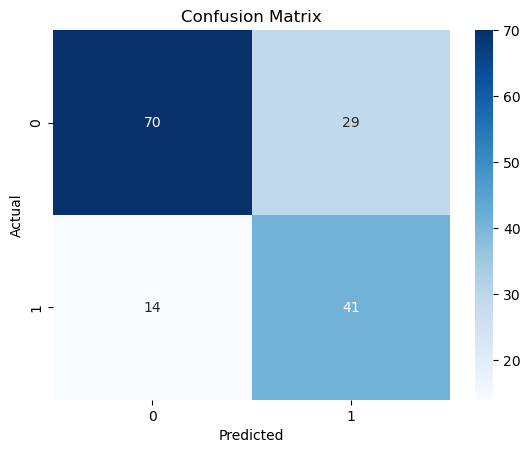

In [13]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC Curve & AUC Score

In [14]:
# Compute ROC curve values

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

y_pred_new = (y_prob >= 0.4).astype(int)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

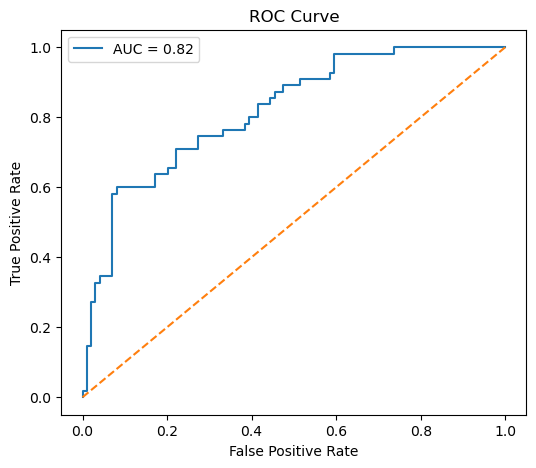

In [15]:
# Plot the ROC curve

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Cross Validation

In [16]:
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print(
    f"Average Accuracy: {scores.mean()}\n"
    "Its actually pretty stable across folds, which is a good sign.\n"
    "The variance is low, meaning the model generalizes consistently.")

[0.75974026 0.74675325 0.77272727 0.79084967 0.76470588]
Average Accuracy: 0.7669552669552668
Its actually pretty stable across folds, which is a good sign.
The variance is low, meaning the model generalizes consistently.


In [17]:
from sklearn.metrics import accuracy_score

# create model
model = LogisticRegression(max_iter=1000)

# train model
model.fit(X_train, y_train)

# predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# accuracies
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.7785016286644951
Testing Accuracy: 0.7532467532467533


In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                        Feature  Coefficient
5                       Age_log     1.486465
6  DiabetesPedigreeFunction_log     0.934055
7             SkinThickness_log     0.312531
4               Pregnancies_log     0.228742
2                           BMI     0.096175
0                       Glucose     0.034867
3                   Insulin_log     0.021024
1                 BloodPressure    -0.012901


# Recommendation
